<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_16_(CPU).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
df = pd.read_csv('/content/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0.0,7.0,0.0,50.0,205.0,196.0,213.0,165.0,0.0,0.0
1,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,1,0,0,0,...,142.0,142.0,142.0,21.0,0.0,3.0,0.0,0.0,0.0,0.0
3,8,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8,0,0,0,0,0,0,0,0,0,...,213.0,203.0,174.0,151.0,188.0,10.0,0.0,0.0,0.0,0.0


In [5]:
df.shape

(2825, 785)

# Basic graph

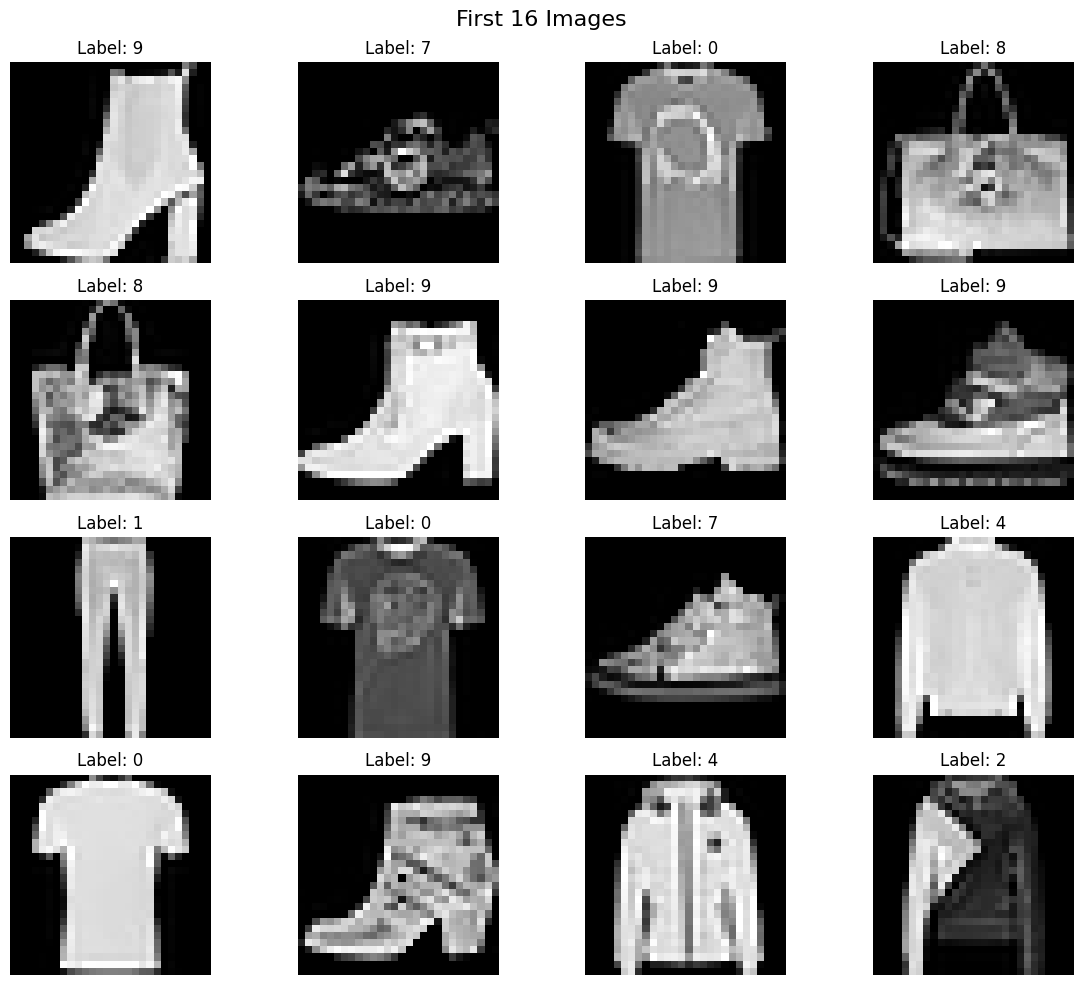

In [6]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize = (12, 10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(img, cmap='gray')
  ax.axis('off')
  ax.set_title(f'Label: {df.iloc[i, 0]}')

plt.tight_layout()
plt.show()

# Train test split

In [7]:
X = df.drop('label', axis=1).values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Feature Scaling

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# Overall workflow

1. Create Dataset
2. Create DataLoader
3. Define model
4. Training Pipeline
5. Evaluation

# Create custom dataset

In [9]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels = torch.tensor(labels, dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [10]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

# Dataloader

In [11]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

# Define Model

In [12]:
class MyNNModel(nn.Module):
  def __init__(self, num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, X):
    return self.model(X)

# Training Pipeline (Instantiate Model)

In [13]:
# defining parameters
learning_rate = 0.1
epochs = 10

# define model
model = MyNNModel(X_train.shape[1])

# define loss function
criterion = nn.CrossEntropyLoss()

# define optimizer
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

### Training loop

In [26]:
for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:
    # forward pass
    output = model(batch_features)

    # calculate loss
    loss = criterion(output, batch_labels)

    # backward
    optimizer.zero_grad()
    loss.backward()

    # update
    optimizer.step()

    # get total loss items
    total_epoch_loss = total_epoch_loss + loss.item()

avg_loss = total_epoch_loss / len(train_loader)
print('Average Loss:', avg_loss)

Average Loss: 0.10592729081465325


# Evaluation

In [15]:
temp = torch.tensor([
                    [0.2,0.1,0.7],
                    [0.2,0.1,0.7]
                    ])

_, predicted = torch.max(temp, 1)
print(_)
print(predicted)

tensor([0.7000, 0.7000])
tensor([2, 2])


In [27]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    output = model(batch_features)
    _, predicted = torch.max(output, 1)

    # total
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

accuracy = 100 * (correct / total)
print(f'Accuracy: {round(accuracy, 4)}')

Accuracy: 82.3009
